In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.metrics import *

%matplotlib inline

In [7]:
# Загрузка
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

# Разделение
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Нормализация
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Для классификации
median = y_train.median()
y_train_class = (y_train > median).astype(int)
y_test_class = (y_test > median).astype(int)

print(f"Данные готовы: обучающая {X_train.shape}, тестовая {X_test.shape}")

Данные готовы: обучающая (16512, 8), тестовая (4128, 8)


In [8]:
linear = LinearRegression()
linear.fit(X_train_scaled, y_train)
y_pred = linear.predict(X_test_scaled)

print("ЛИНЕЙНАЯ РЕГРЕССИЯ")
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")

ЛИНЕЙНАЯ РЕГРЕССИЯ
MSE: 0.5559
RMSE: 0.7456
MAE: 0.5332


In [9]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

print("RIDGE РЕГРЕССИЯ")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_ridge)):.4f}")

RIDGE РЕГРЕССИЯ
RMSE: 0.7456


In [10]:
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_scaled, y_train_class)
y_pred_class = logreg.predict(X_test_scaled)

print("КЛАССИФИКАЦИЯ")
print(f"Accuracy: {accuracy_score(y_test_class, y_pred_class):.4f}")
print(f"Precision: {precision_score(y_test_class, y_pred_class):.4f}")
print(f"Recall: {recall_score(y_test_class, y_pred_class):.4f}")
print(f"F1-score: {f1_score(y_test_class, y_pred_class):.4f}")

КЛАССИФИКАЦИЯ
Accuracy: 0.8263
Precision: 0.8259
Recall: 0.8239
F1-score: 0.8249


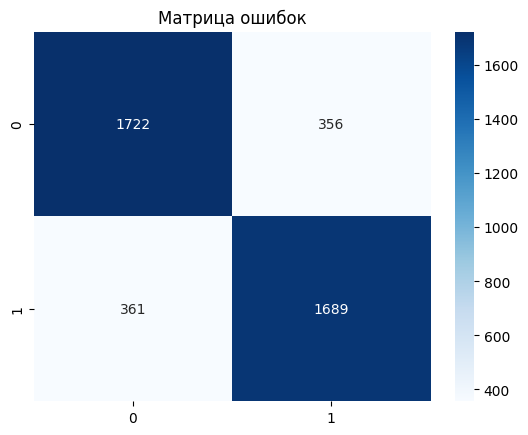

In [11]:
cm = confusion_matrix(y_test_class, y_pred_class)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок')
plt.show()

In [12]:
logreg_bal = LogisticRegression(class_weight='balanced', max_iter=1000)
logreg_bal.fit(X_train_scaled, y_train_class)
y_pred_bal = logreg_bal.predict(X_test_scaled)

print("УЛУЧШЕННАЯ КЛАССИФИКАЦИЯ")
print(f"Accuracy: {accuracy_score(y_test_class, y_pred_bal):.4f}")
print(f"Recall: {recall_score(y_test_class, y_pred_bal):.4f}")

УЛУЧШЕННАЯ КЛАССИФИКАЦИЯ
Accuracy: 0.8263
Recall: 0.8239


In [13]:
print("="*40)
print("ИТОГИ ЛАБОРАТОРНОЙ РАБОТЫ")
print("="*40)
print(f"1. Регрессия: RMSE = {np.sqrt(mean_squared_error(y_test, y_pred_ridge)):.4f}")
print(f"2. Классификация: Accuracy = {accuracy_score(y_test_class, y_pred_class):.4f}")
print(f"3. Лучший признак: MedInc (доход)")

ИТОГИ ЛАБОРАТОРНОЙ РАБОТЫ
1. Регрессия: RMSE = 0.7456
2. Классификация: Accuracy = 0.8263
3. Лучший признак: MedInc (доход)
